<a href="https://colab.research.google.com/github/Amarmurun0212/Diver/blob/main/AI%26MLLes8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Шугаман регресс

## Шугаман регресс гэдэг нь нэг хувьсагчийн (хамааралтай хувьсагч y) утга нь нэг эсвэл хэд хэдэн бусад хувьсагчийн (x — хүчин зүйл, тайлбарлагч хувьсагч) нөлөөнөөс хэрхэн өөрчлөгдөж байгааг шугаман хамаарлаар илэрхийлдэг математик загвар юм.

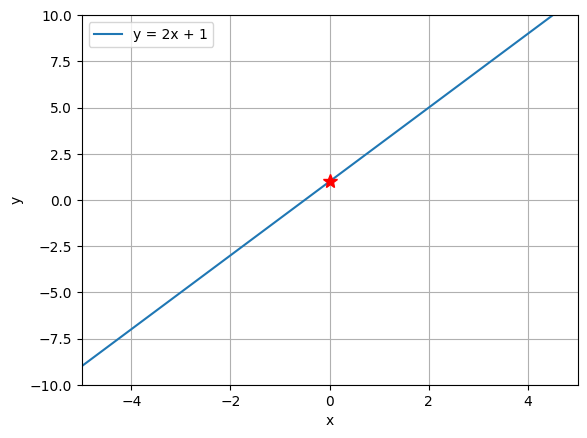

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(-6, 6)
a = 2
b = 1

y = a * x + b
plt.plot(x, y, label=f'y = {a}x + {b}')
plt.plot([0], [b], 'r*', markersize=10)
plt.ylabel('y');plt.xlabel('x')
plt.ylim(-10, 10);plt.xlim(-5, 5)
plt.grid()
plt.legend();

Шилжилтийн коэффициент (b)

Хэрэв шилжилтийн коэффициент b=0 бол шулуун нь (0,0) цэгээр дайрч өнгөрнө.
Хэрэв b нь 0 биш, жишээлбэл b=2 бол шулуун нь (0,2) цэгээр дайрна.

Налалтын коэффициент (a)

Хэрэв налалтын коэффициент a=0 бол шулуун нь Ox тэнхлэгтэй параллель байна.
Хэрэв a>0 бол шулуун өсөх чиглэлтэй байна. a-гийн утга их байх тусам шулууны налуу огцом болно.
Хэрэв a<0 бол шулуун буурах чиглэлтэй байна. a-гийн утга бага (илүү сөрөг) байх тусам шулууны налуу илүү огцом болно.

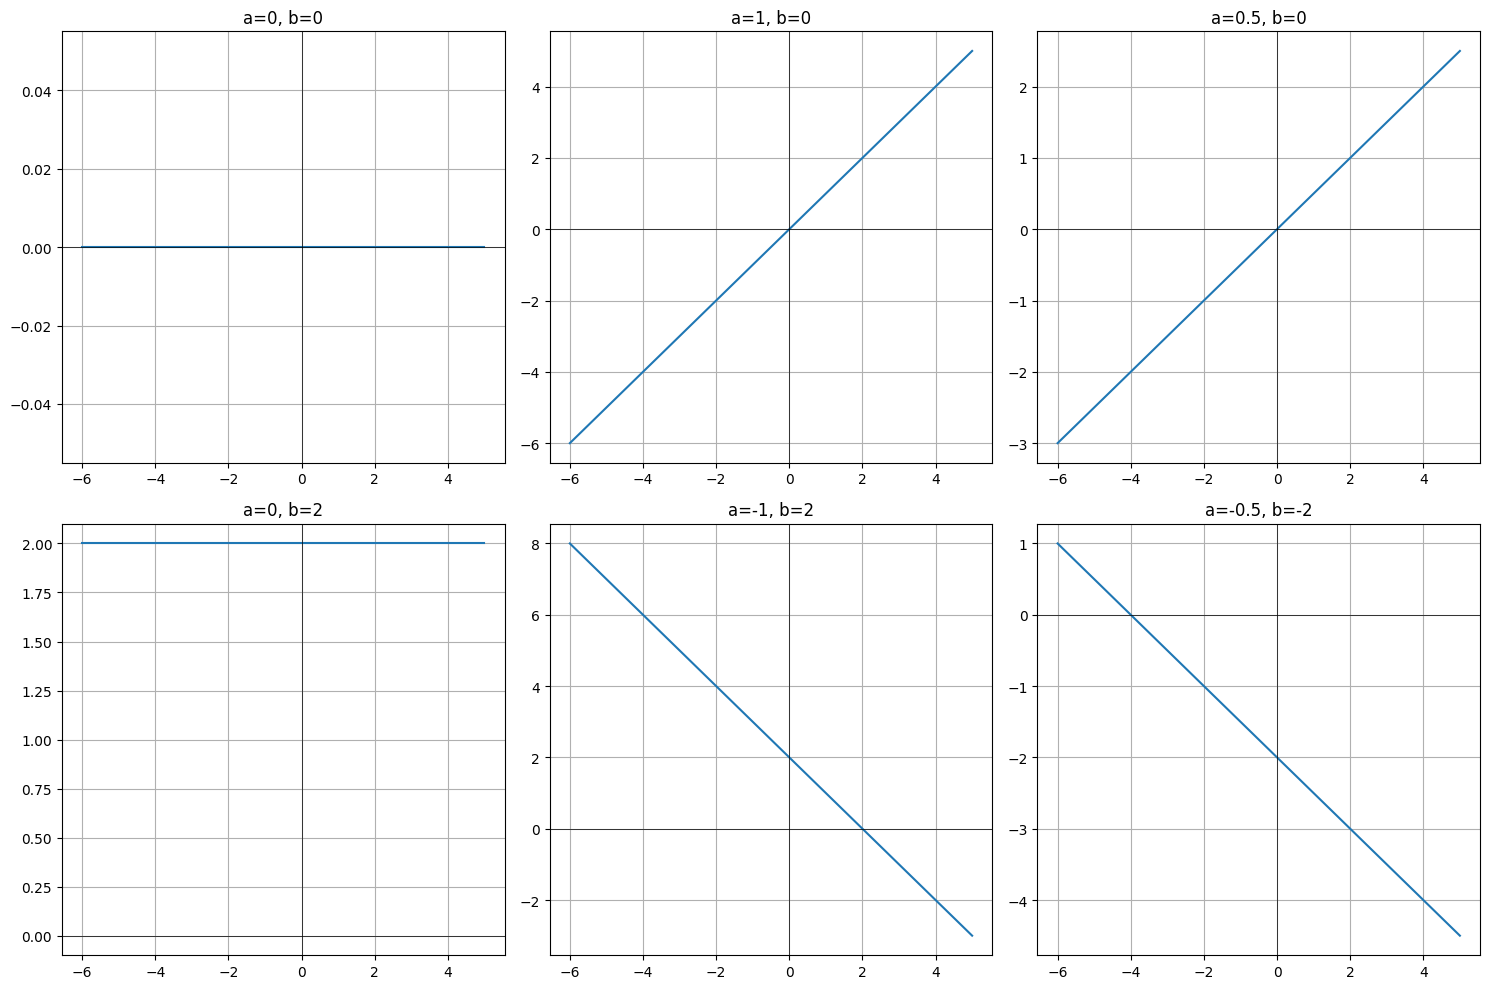

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# График зурах функц
def draw_ax(a, b, x, ax):
    y = a * x + b

    ax.plot(x, y)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
'''
ax.axhline(0, color='black', linewidth=0.5)
ax → графикийн тэнхлэгийн объект (axes object)
axhline() → хэвтээ шугам зурах функц
0 → y=0 байрлалд шугам зурна
color='black' → шугамын өнгө хар
linewidth=0.5 → шугамын зузаан 0.5

axvline() → босоо шугам зурах функц
0 → x=0 байрлалд зурна

ax.set_title(f'a={a}, b={b}')
set_title() → графикийн гарчиг тохируулна
f'...' → f-string буюу хувьсагчийн утгыг текстэнд оруулах Python хэлбэр
a={a}, b={b} → a болон b хувьсагчийн утгыг гарчигт харуулна

'''
    ax.set_title(f'a={a}, b={b}')
    ax.grid(True)


fig, ax = plt.subplots(2, 3, figsize=(15, 10))
x = np.arange(-6, 6)

# 1 мөр
a, b = 0, 0
draw_ax(a, b, x, ax[0][0])

a, b = 1, 0
draw_ax(a, b, x, ax[0][1])

a, b = 0.5, 0
draw_ax(a, b, x, ax[0][2])

# 2 мөр
a, b = 0, 2
draw_ax(a, b, x, ax[1][0])

a, b = -1, 2
draw_ax(a, b, x, ax[1][1])

a, b = -0.5, -2
draw_ax(a, b, x, ax[1][2])

plt.tight_layout()
plt.show()

Шулууны тэгшитгэлтэй танилцсан тул одоо шугаман регрессийг “сургаж” үзье. Учир нь шугаман регресс нь үндсэндээ шулуун шугам юм.

# Дата үүсгэе

Одоо бид өөрсдөө өгөгдөл үүсгээд, тэр өгөгдөл дээрээ шугаман загвар сургаж үзье.

Өөрөөр хэлбэл:

x болон y утгуудыг хиймлээр үүсгэнэ.
Эдгээр өгөгдлийн хоорондын хамаарлыг ашиглан шугаман регрессийн загвар байгуулна.
Загвар нь хамгийн тохиромжтой шулууг олж сурна.

In [ ]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=50, n_features=1, n_informative=1,
                       noise=10, random_state=11)

print(X, y)
'''
random_state = 11
туршилтаа дахин давтах,
бусадтай ижил үр дүн авах,
сургалтын жишээг тогтвортой байлгахын тулд ашигладаг.
'''

[[ 0.63007982]
 [-1.06163445]
 [ 0.29634711]
 [ 1.40277112]
 [ 0.68968231]
 [-0.53662936]
 [-1.11947526]
 [ 1.06755846]
 [ 0.1178195 ]
 [ 1.54907163]
 [ 1.29561858]
 [-0.03107509]
 [ 0.56119218]
 [ 0.42105072]
 [-0.4864951 ]
 [ 0.08897764]
 [-0.18577532]
 [-0.17809318]
 [-0.23725045]
 [-0.88623967]
 [-0.47573349]
 [ 0.21734821]
 [-2.65331856]
 [ 0.72575222]
 [-0.38053642]
 [-0.48456513]
 [ 1.57463407]
 [-1.30554851]
 [-0.17241977]
 [ 0.73683739]
 [-1.23234621]
 [ 0.31540267]
 [ 1.74945474]
 [ 0.09183837]
 [-0.30957664]
 [-1.18575527]
 [-0.68344663]
 [-0.31963136]
 [-0.00828463]
 [-0.64257539]
 [ 1.0956297 ]
 [ 0.06367166]
 [-0.57395456]
 [ 0.07349324]
 [ 0.73227135]
 [-1.06560298]
 [-1.68411089]
 [-1.54686257]
 [-0.20437532]
 [-0.286073  ]] [  43.6543408   -72.68235021   21.19644643  107.58765071   69.62063217
  -32.57566222 -101.61213107   87.44514699   17.69898683  131.00190463
   97.97802247    2.70819092   52.42715419   27.74476129  -31.82947365
    1.58209228   -9.72570848    4.57

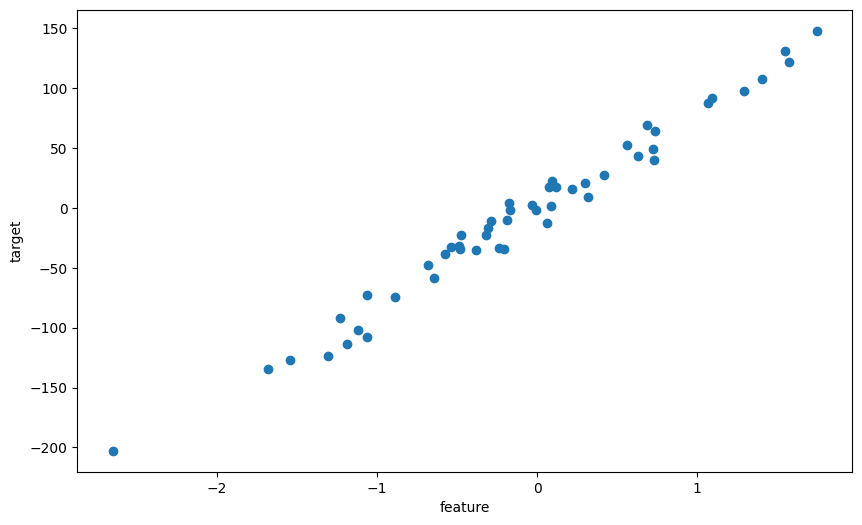

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 6))
plt.scatter(X, y)

plt.xlabel('feature')
plt.ylabel('target')
plt.show()

Нэг хэмжээст шугаман регресс гэдэг нь нэг л оролтын хувьсагч (x) ашиглан гаралтын хувьсагч (y)-ийг таамаглах шугаман загвар юм.

scikit-learn сангийн linear_model модулиас LinearRegression загварыг авъя.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model

LinearRegression()

In [ ]:
model.fit(X, y)

LinearRegression()

Ингээд загвар сурч дууслаа. Энэ үйл явц маш хурдан явагддаг.

Шугаман загварыг сургах гэдэг нь үндсэндээ коэффициентүүдийн хамгийн тохиромжтой утгыг олох процесс юм.

Нэг хэмжээст шугаман регрессийн хувьд эдгээр нь:

In [ ]:
model.coef_, model.intercept_

(array([80.41862354]), np.float64(0.1817188754210024))

In [ ]:
model_a = model.coef_[0]
model_b = model.intercept_

Энэ шулуун нь сургалтын өгөгдлийн цэгүүдийн дагуу хамгийн сайн байдлаар тааруулан байгуулагдсан байна.

Өөрөөр хэлбэл, шугаман регрессийн загвар нь өгөгдлийн цэгүүдэд аль болох ойрхон өнгөрөх шулууг олсон гэсэн үг.

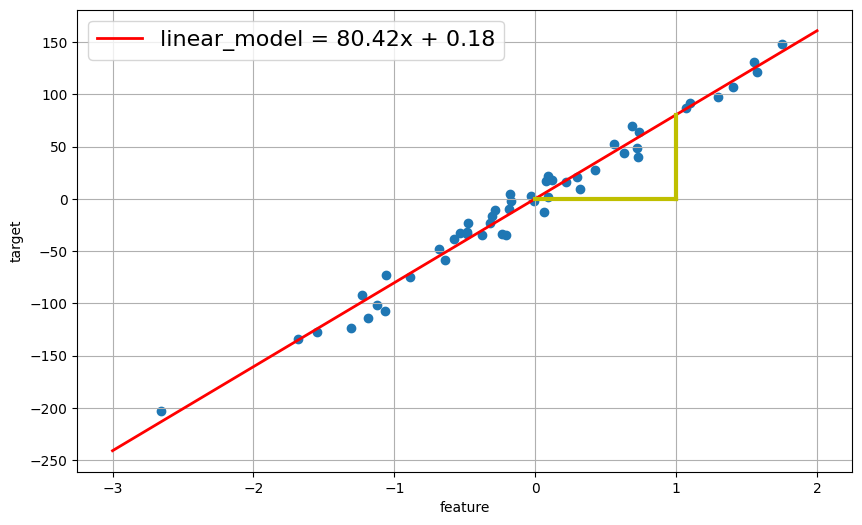

In [ ]:
fig = plt.figure(figsize=(10, 6))

x = np.arange(-3, 3)
model_y_sk = model_a * x + model_b

plt.plot(x, model_y_sk, linewidth=2, c='r', label=f'linear_model = {model_a:.2f}x + {model_b:.2f}')
'''
Тайлбар:

plt.plot(...)
График дээр шугам зурна.
x
x-ийн утгууд.
model_y_sk
Загварын тооцоолсон y-ийн утгууд.
linewidth=2
Шугамын зузааныг 2 болгож байна.
c='r'
Шугамын өнгийг улаан (red) болгож байна.
label=...
Графикийн тайлбар (legend) дээр харагдах нэр.
{model_a:.2f} → model_a-г таслалаас хойш 2 оронтой харуулна
{model_b:.2f} → model_b-г мөн 2 оронтой харуулна
'''
plt.scatter(X, y)
plt.plot([0, 1], [model_b, model_b], 'y', linewidth=3)
plt.plot([1, 1], [model_b, model_b+model_a], 'y', linewidth=3)
plt.grid()
plt.xlabel('feature')
plt.ylabel('target')
plt.legend(prop={'size': 16})
plt.show()

Одоо энэ загвараар таамаглал хийхийн тулд predict() методыг дуудаж, түүнд өгөгдлөө дамжуулахад хангалттай.

In [ ]:
print(model.predict(X[:1]))
'''X[:1]
X массивын эхний 1 элементийг авна.
'''''

[50.85187092]


'X[:1]\nX массивын эхний 1 элементийг авна.\n'

Одоо албаар буруу шугам татаж үзээд дундаж квадрат алдааг олоё

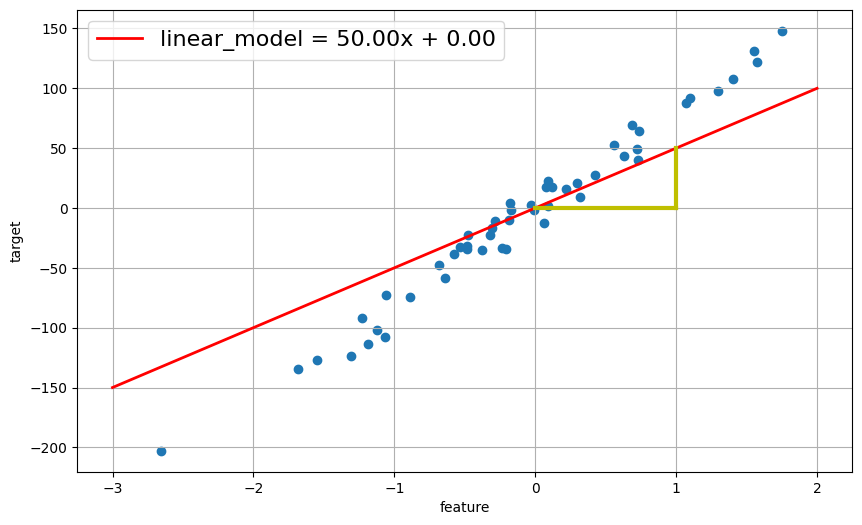

In [ ]:
fig = plt.figure(figsize=(10, 6))

x = np.arange(-3, 3)
a, b = 50, 0
model_y = a * x + b

plt.plot(x, model_y, linewidth=2, c='r', label=f'linear_model = {a:.2f}x + {b:.2f}')
plt.scatter(X, y)
plt.plot([0, 1], [b, b], 'y', linewidth=3)
plt.plot([1, 1], [b, b+a], 'y', linewidth=3)
plt.grid()
plt.xlabel('feature')
plt.ylabel('target')
plt.legend(prop={'size': 16})
plt.show()

Харин дүрслэлээр харахад энэ нь цэнхэр цэгүүдээс илүү их хазайлттай мэт байна. Тэгвэл зөвхөн нүдээр харах биш, тоон утгаар нь харьцуулж үзье.

Эхлээд бүх өгөгдлийг нэг хүснэгтэд оруулъя.

X — загвар байгуулахад ашиглаж буй цэгүүд
y — бидний таамаглахыг хүсэж буй бодит зорилтот хувьсагч
pred_model_good — эхний загварын (LinearRegression) X координатууд дээрх таамагласан утгууд
pred_bad_model — хоёр дахь загварын X координатууд дээрх утгууд бөгөөд энэ загварыг scikit-learn ашиглалгүйгээр гараар үүсгэсэн болно.

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'X': X[:,0],
    '''
Тайлбар:
: → бүх мөр
0 → эхний багана
    '''
    'y': y,
    'pred_good_model': model_a * X[:,0] + model_b,
    'pred_bad_model': a * X[:,0] + b
})


df.head()

,X,y,pred_good_model,pred_bad_model
0,0.630080,43.654341,50.851871,31.503991
1,-1.061634,-72.682350,-85.193462,-53.081722
2,0.296347,21.196446,24.013545,14.817355
3,1.402771,107.587651,112.990641,70.138556
4,0.689682,69.620632,55.645021,34.484116


Одоо загвар бүрийн таамаглал бодит утгаас хэр хэмжээгээр хазайж байгааг тооцоолъё.

Мөн эхний 5 өгөгдөл дээр харахад scikit-learn ашигласан загварын хазайлт нь хоёр дахь загвараас бага байна.

residual → үлдэгдэл алдаа

In [ ]:
df['residual_good'] = df['pred_good_model'] - df['y']
df['residual_bad'] = df['pred_bad_model'] - df['y']
df.head()

,X,y,pred_good_model,pred_bad_model,residual_good,residual_bad
0,0.630080,43.654341,50.851871,31.503991,7.197530,-12.150350
1,-1.061634,-72.682350,-85.193462,-53.081722,-12.511112,19.600628
2,0.296347,21.196446,24.013545,14.817355,2.817099,-6.379091
3,1.402771,107.587651,112.990641,70.138556,5.402991,-37.449095
4,0.689682,69.620632,55.645021,34.484116,-13.975611,-35.136517


Одоо бүх объект дээр загварын чанарыг үнэлэх нэг метрик тооцоолж үзье.

Бид MSE (mean squared error) буюу дундаж квадрат алдаа-г ашиглана. Энэ талаар илүү дэлгэрэнгүйг энэ видеон дээр болон энэ notebook дээр тайлбарласан байгаа.

In [ ]:
print(np.mean(df['residual_good'] ** 2))

111.93097544862604


In [ ]:
print(np.mean(df['residual_bad'] ** 2))

873.1554374932329


scikit-learn-ийн загвар яаж ийм чанартай таамаглал гаргаж чадсан юм бол? Эцсийн эцэст түүнд шулууг байгуулах маш олон боломж байсан — налалтын болон шилжилтийн коэффициентийг дурын байдлаар өөрчилж болно шүү дээ.

Хариулт нь — оновчлолын (optimization) аргууд юм.

Учир нь MSE алдаа нь өөрөө нэг төрлийн функц бөгөөд энэ нь налалтын болон шилжилтийн коэффициентээс хамаарч өөрчлөгдөнө.

Бид шилжилтийн коэффициент болон налалтын коэффициентын 100 өөр өөр утгуудыг авч, тус бүр дээр MSE-г тооцоолж, тэдгээрийг 3 хэмжээст график дээр дүрслэх боломжтой.

Мөн түүн дээр scikit-learn-ийн загварын олсон коэффициентууд болон бидний гараар сонгосон коэффициентуудыг ч мөн дүрслэн харуулна.

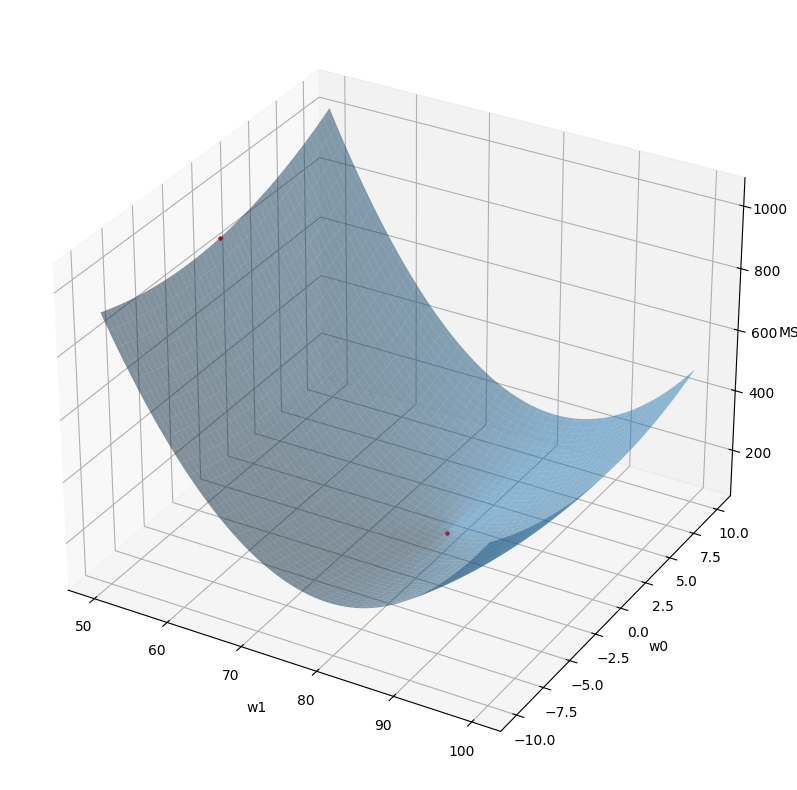

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D
# Matplotlib-ийн 3D график зурах хэрэгсэл, Axes3D → 3 хэмжээст координатын систем үүсгэнэ

def mse(w1, w0):
    y_pred = w1 * X[:, 0] + w0
    return np.mean((y - y_pred) ** 2)


coefs_a = np.linspace(50, 100, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)
# meshgrid = “коэффициентүүдийн бүх боломжит хослолын тор үүсгэгч”
'''
coefs_a = [1, 2]   # w1
coefs_b = [10, 20] # w0
meshgrid-ийн үр дүн:
w1:
[[1, 2],
 [1, 2]]
w0:
[[10, 10],
 [20, 20]]
'''

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
# “Нэг зураг дотор нэг 3D график байрлуул” гэсэн утгатай

zs = np.array([mse(i, j) for i, j in zip(np.ravel(w1), np.ravel(w0))])
Z = zs.reshape(w1.shape)
'''
NumPy-ийн ravel() функц нь олон хэмжээст массивыг 1 хэмжээст (flat) вектор болгон хувиргадаг функц юм.
a = np.array([[1, 2, 3],
              [4, 5, 6]])
print(a.ravel())
zip:
w1  ба w0 -ийн хосуудыг нэг нэгээр нь нийлүүлнэ
reshape:
reshape хийх шаардлага гарч байгаа гол шалтгаан нь өгөгдлийн хэлбэр (shape) зөрж байгаа юм.

'''

ax.plot_surface(w1, w0, Z, alpha=0.5)
# surface гэдэг нь 3 хэмжээст гадаргуу гэсэн утгатай. alpha нь тунгалаг харагадац
ax.scatter(model_a, model_b, mse(model_a, model_b), c='r', s=5)
# s=5 гэдэг нь цэгийн хэмжээ (size)-г заадаг параметр юм.
ax.scatter(a, b, mse(a, b), c='r', s=5)

ax.set_xlabel('w1')
ax.set_ylabel('w0')
ax.set_zlabel('MSE')

plt.show()

# Multible linear regression

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 300  # өгөгдлийн мөрийн тоо

area_m2 = np.random.randint(30, 250, n)
num_occupants = np.random.randint(1, 8, n)
avg_temp = np.random.randint(-25, 35, n)
insulation = np.random.randint(1, 6, n)
appliances_count = np.random.randint(5, 30, n)
solar_panel = np.random.randint(0, 2, n)
humidity = np.random.randint(20, 90, n)

# --- Linear relationship (energy consumption model)
noise = np.random.normal(0, 30, n)

energy_kwh = (
    5 * area_m2 +
    120 * num_occupants -
    3 * avg_temp -
    40 * insulation +
    8 * appliances_count -
    150 * solar_panel +
    0.5 * humidity +
    noise
)

df = pd.DataFrame({
    "area_m2": area_m2,
    "num_occupants": num_occupants,
    "avg_temp": avg_temp,
    "insulation": insulation,
    "appliances_count": appliances_count,
    "solar_panel": solar_panel,
    "humidity": humidity,
    "energy_kwh": energy_kwh.round(2)
})

print(df.head())

# CSV хадгалах
df.to_csv("energy_data.csv", index=False)

   area_m2  num_occupants  avg_temp  insulation  appliances_count  \
0      132              1        -6           5                 8   
1      209              3        -2           2                26   
2      122              4       -14           1                 6   
3       44              1        24           3                14   
4      136              1         9           3                 9   

   solar_panel  humidity  energy_kwh  
0            1        80      568.31  
1            0        54     1554.88  
2            1        69     1047.65  
3            1        81       65.04  
4            1        36      627.46  


📊 Оруулах хувьсагчид (features)

Бид дараах хүчин зүйлсийг ашиглая:

area_m2 — байрны талбай (м²)
num_occupants — оршин суугчдын тоо
avg_temp — дундаж температур (°C)
insulation — дулаан тусгаарлалт (1–5)
appliances_count — цахилгаан хэрэгслийн тоо
solar_panel — нарны панель байгаа эсэх (0/1)
humidity — чийгшил (%)

🎯 Target:

energy_kwh — сарын цахилгаан хэрэглээ (kWh)

In [ ]:
# ============================================
# 1. Excel/CSV файл унших
# ============================================
import pandas as pd
# CSV файл унших
df = pd.read_csv('/content/energy_data.csv')
# Хэрэв Excel файл бол:
# df = pd.read_excel('/content/energy_data.xlsx')

# ============================================
# 2. energy_kwh-тэй корреляци тооцох
# ============================================

correlation = df.corr(numeric_only=True)['energy_kwh'].sort_values(ascending=False)

print("energy_kwh-тэй корреляц:")
print(correlation)

# ============================================
# 3. Илүү гоё хүснэгтээр харах
# ============================================

corr_df = correlation.reset_index()
corr_df.columns = ['Variable', 'Correlation_with_energy_kwh']

print("\n=== Correlation Table ===")
print(corr_df)

energy_kwh-тэй корреляц:
energy_kwh          1.000000
area_m2             0.759594
num_occupants       0.582570
appliances_count    0.140919
humidity            0.134700
avg_temp           -0.146696
solar_panel        -0.175247
insulation         -0.202017
Name: energy_kwh, dtype: float64

=== Correlation Table ===
           Variable  Correlation_with_energy_kwh
0        energy_kwh                     1.000000
1           area_m2                     0.759594
2     num_occupants                     0.582570
3  appliances_count                     0.140919
4          humidity                     0.134700
5          avg_temp                    -0.146696
6       solar_panel                    -0.175247
7        insulation                    -0.202017


In [ ]:
df

,area_m2,num_occupants,avg_temp,insulation,appliances_count,solar_panel,humidity,energy_kwh
0,132,1,-6,5,8,1,80,568.31
1,209,3,-2,2,26,0,54,1554.88
2,122,4,-14,1,6,1,69,1047.65
3,44,1,24,3,14,1,81,65.04
4,136,1,9,3,9,1,36,627.46
...,...,...,...,...,...,...,...,...
295,190,7,-8,1,25,0,21,2007.27
296,197,2,6,5,11,0,56,1105.70
297,157,1,21,5,14,0,88,720.27
298,68,4,23,3,17,0,57,779.11


In [ ]:
import matplotlib.pyplot as plt

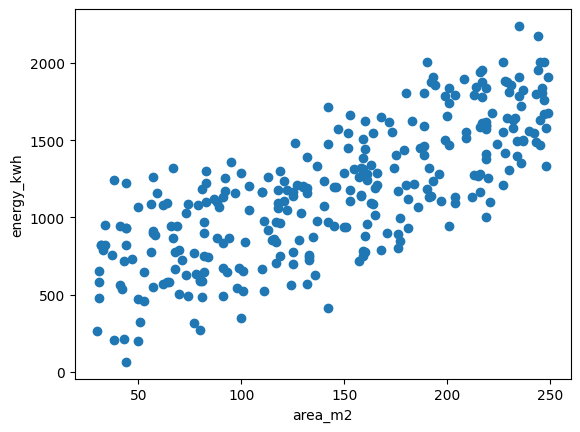

In [ ]:
a = df['area_m2']
b = df['energy_kwh']
plt.scatter(a, b)
plt.xlabel('area_m2')
plt.ylabel('energy_kwh')
plt.show()

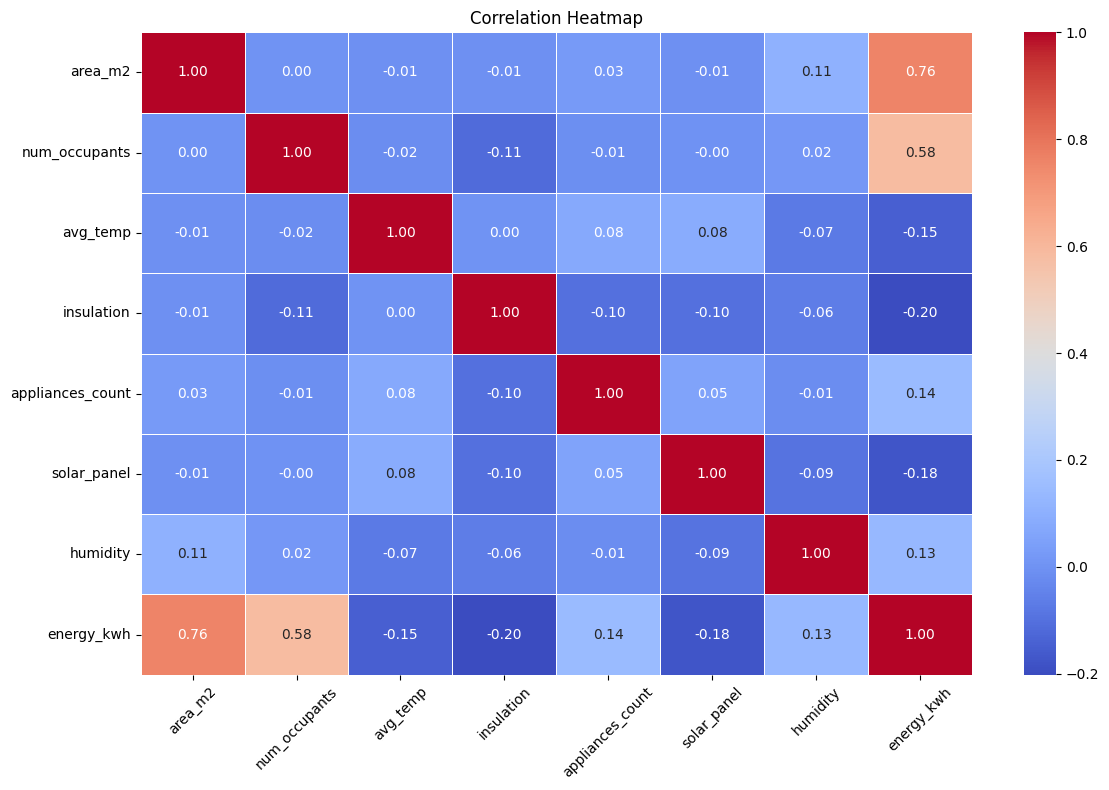

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,          # correlation value харуулах
    fmt=".2f",           # 2 орны нарийвчлал
    cmap="coolwarm",     # өнгөний theme
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


R² Score: 0.9944


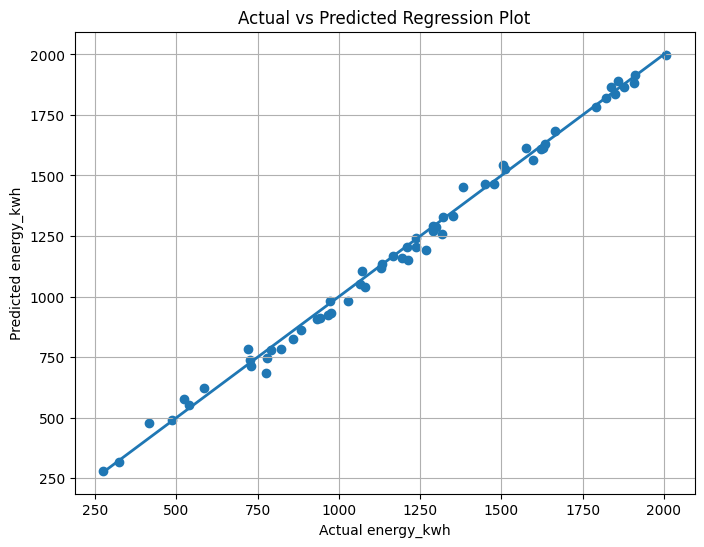

In [ ]:
# ============================================
# 1. Library import
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ============================================
# 2. Файл унших
# ============================================

# CSV файл
df = pd.read_csv('/content/energy_data.csv')

# Хэрэв Excel файл бол:
# df = pd.read_excel('/content/energy_data.xlsx')

# ============================================
# 3. Feature болон Target
# ============================================

y = df['energy_kwh']
X = df.drop(columns=['energy_kwh'])

# categorical -> numeric
X = pd.get_dummies(X, drop_first=True)
# эхний мөрийг хас
'''Machine Learning model ихэнхдээ:
text/string өгөгдөл ойлгодоггүй
зөвхөн numeric (тоо) өгөгдөл дээр ажилладаг
'''
# ============================================
# 4. Train/Test split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================
# 5. Model train
# ============================================

model = LinearRegression()

model.fit(X_train, y_train)

# ============================================
# 6. Prediction
# ============================================

y_pred = model.predict(X_test)

# ============================================
# 7. R² score
# ============================================

r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
'''
R² Score	Тайлбар
1.0	Perfect prediction
0.9	Маш сайн
0.7	Сайн
0.5	Дундаж
0.0	Ямар ч тайлбар хийж чадаагүй
< 0	Маш муу model
'''

# ============================================
# 8. Regression Plot
# ============================================

plt.figure(figsize=(8,6))

# Actual vs Predicted scatter plot
plt.scatter(y_test, y_pred)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linewidth=2
)

plt.xlabel("Actual energy_kwh")
plt.ylabel("Predicted energy_kwh")
plt.title("Actual vs Predicted Regression Plot")

plt.grid(True)

plt.show()

In [ ]:
new_data = pd.DataFrame({
    'area_m2': [120],
    'num_occupants': [4],
    'appliances_count': [10],
    'humidity': [55],
    'avg_temp': [15],
    'solar_panel': [1],
    'insulation': [3]
})

# ============================================
# Training feature-тэй ижил column болгох
# ============================================

# Хэрэв categorical feature байвал encoding хийх
new_data = pd.get_dummies(new_data)

# Training үед ашигласан feature column-уудтай тааруулах
new_data = new_data.reindex(columns=X.columns, fill_value=0)

# ============================================
# Prediction хийх
# ============================================

predicted_energy = model.predict(new_data)

print("Predicted energy_kwh:")
print(predicted_energy[0])

Predicted energy_kwh:
869.7683821955331
